# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test9 validation legacy

Notebook equivalent of `tests/4_earth/test9_validation_legacy.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `earth` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `earth` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing import paths for the editable package.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test9_validation_legacy"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "4_earth" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\4_earth\test9_validation_legacy.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `earth` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\earth\test9_validation_legacy


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_legacy_import_and_objects`

**What is checked:** Legacy import and objects behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Legacy density must contain earth shells; Legacy PMNS matrix must have shape (3, 3).

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; legacy/reference-data comparisons may fail if optional reference inputs or conventions change.


In [4]:
run_notebook_test(TEST_MODULE.test_legacy_import_and_objects)


Running test_legacy_import_and_objects ...
Warning!: Python module pyslha not found, disabling slha reading routines

Legacy import check:
legacy pmns module : <module 'peanuts.pmns' from 'G:\\Mi unidad\\03.Codigo\\034.TFM.UV\\Tpeanuts\\peanuts\\pmns.py'>
legacy earth module: <module 'peanuts.earth' from 'G:\\Mi unidad\\03.Codigo\\034.TFM.UV\\Tpeanuts\\peanuts\\earth.py'>
legacy density rj shape: (5,)
legacy PMNS matrix shape: (3, 3)
------------------------------------------------------------------------------------------
PASSED: test_legacy_import_and_objects


## Test: `test_legacy_torch_probability_precision`

**What is checked:** Legacy torch probability precision behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Torch and legacy probabilities must agree in absolute precision; Torch and legacy probabilities must agree in relative precision; Raw torch probabilities must remain close to normalized; Raw legacy probabilities must remain close to normalized; and additional consistency checks.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; legacy/reference-data comparisons may fail if optional reference inputs or conventions change; normalization failures often point to probability conservation or broadcasting issues.


In [5]:
run_notebook_test(TEST_MODULE.test_legacy_torch_probability_precision)


Running test_legacy_torch_probability_precision ...

Computing legacy-vs-torch earth probabilities:
Energy [MeV]  : 1000.0
Depth [m]     : 0.0
Torch density file  : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\density\earth_density.csv
Legacy density file : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\peanuts\earth_density.csv
Legacy folder : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\peanuts

Initial flavour: nu_e
  eta=0.100 rad | legacy=[0.9742037502 0.0162173147 0.0103005142] | torch=[0.9742037502 0.0162173147 0.0103005142] | max_abs_diff=1.066e-14
  eta=0.350 rad | legacy=[0.7983936625 0.0658671174 0.1364145689] | torch=[0.7983936625 0.0658671174 0.1364145689] | max_abs_diff=1.221e-15
  eta=0.600 rad | legacy=[0.9365395396 0.0518721283 0.0124362514] | torch=[0.9365395396 0.0518721283 0.0124362514] | max_abs_diff=1.410e-14
  eta=0.850 rad | legacy=[0.9026508161 0.0718685866 0.0255556325] | torch=[0.9026508161 0.0718685866 0.0255556325] | max_abs_diff=2.554e-15
  eta=1.100 rad

## Test: `test_each_flavour_angle_probability_is_finite`

**What is checked:** Each flavour angle probability is finite behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Torch probabilities must be finite; Legacy probabilities must be finite; Torch probabilities must be non-negative within tolerance; Legacy probabilities must be non-negative within tolerance.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [6]:
run_notebook_test(TEST_MODULE.test_each_flavour_angle_probability_is_finite)


Running test_each_flavour_angle_probability_is_finite ...

Finite and normalized probability checks:
nu_e   eta=0.100 | sum_torch=1.000721579062 | sum_legacy=1.000721579062
nu_e   eta=0.350 | sum_torch=1.000675348751 | sum_legacy=1.000675348751
nu_e   eta=0.600 | sum_torch=1.000847919285 | sum_legacy=1.000847919285
nu_e   eta=0.850 | sum_torch=1.000075035147 | sum_legacy=1.000075035147
nu_e   eta=1.100 | sum_torch=1.000006440727 | sum_legacy=1.000006440727
nu_e   eta=1.350 | sum_torch=1.000000019124 | sum_legacy=1.000000019124
nu_mu  eta=0.100 | sum_torch=1.000288883316 | sum_legacy=1.000288883316
nu_mu  eta=0.350 | sum_torch=1.000380400525 | sum_legacy=1.000380400525
nu_mu  eta=0.600 | sum_torch=1.000501960266 | sum_legacy=1.000501960266
nu_mu  eta=0.850 | sum_torch=1.000057499362 | sum_legacy=1.000057499362
nu_mu  eta=1.100 | sum_torch=1.000002917956 | sum_legacy=1.000002917956
nu_mu  eta=1.350 | sum_torch=1.000000011996 | sum_legacy=1.000000011996
nu_tau eta=0.100 | sum_torch=1.0004

## Plot: `plot_probability_curves_by_initial_flavour()`

**What is checked:** Probability curves by initial flavour behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_legacy_validation_probability_curves.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_probability_curves_by_initial_flavour()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_legacy_validation_probability_curves.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_probability_curves_by_initial_flavour() ...
Saved plot: V:\output\test\earth\test9_validation_legacy\plot_probability_curves_by_initial_flavour_figure_001.png


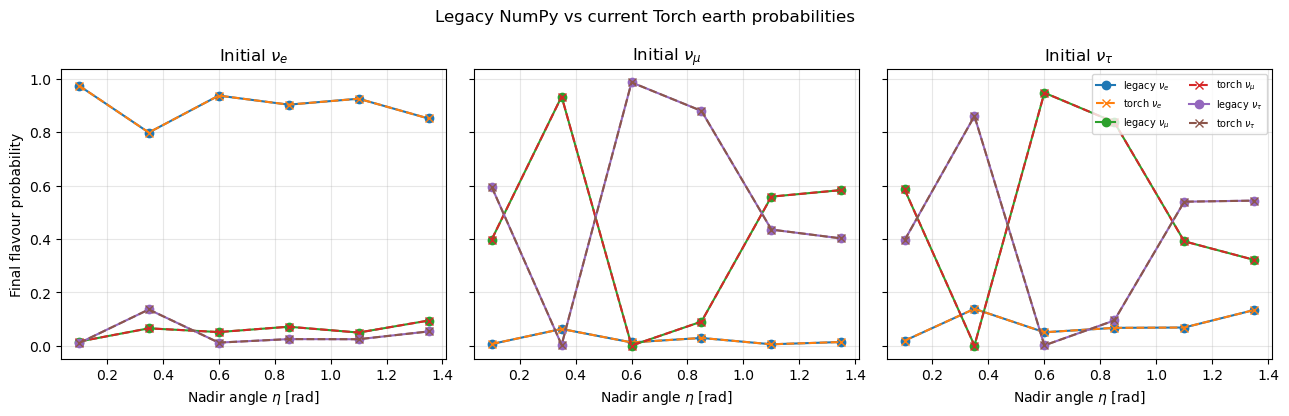

PASSED: plot_probability_curves_by_initial_flavour()


In [7]:
run_notebook_call('plot_probability_curves_by_initial_flavour()', lambda: TEST_MODULE.plot_probability_curves_by_initial_flavour())


## Plot: `plot_absolute_error_by_initial_flavour()`

**What is checked:** Absolute error by initial flavour behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_legacy_validation_absolute_error.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_absolute_error_by_initial_flavour()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_legacy_validation_absolute_error.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_absolute_error_by_initial_flavour() ...
Saved plot: V:\output\test\earth\test9_validation_legacy\plot_absolute_error_by_initial_flavour_figure_001.png


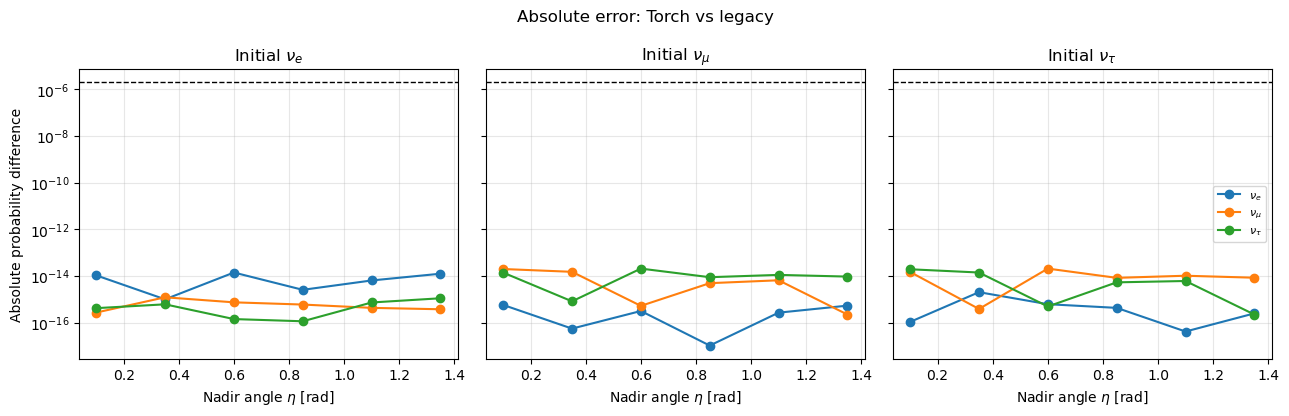

PASSED: plot_absolute_error_by_initial_flavour()


In [8]:
run_notebook_call('plot_absolute_error_by_initial_flavour()', lambda: TEST_MODULE.plot_absolute_error_by_initial_flavour())


## Plot: `plot_max_error_heatmap()`

**What is checked:** Max error heatmap behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_legacy_validation_max_error_heatmap.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_max_error_heatmap()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_legacy_validation_max_error_heatmap.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_max_error_heatmap() ...
Saved plot: V:\output\test\earth\test9_validation_legacy\plot_max_error_heatmap_figure_001.png


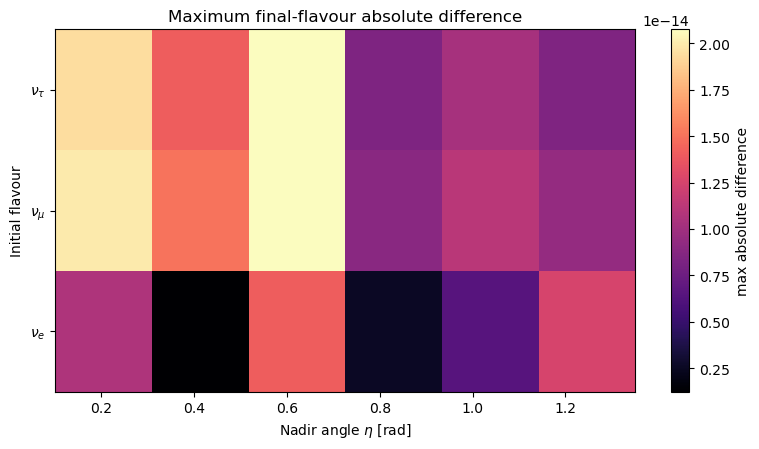

PASSED: plot_max_error_heatmap()


In [9]:
run_notebook_call('plot_max_error_heatmap()', lambda: TEST_MODULE.plot_max_error_heatmap())
